## References
Dataset: https://huggingface.co/datasets/dair-ai/emotion

Model: https://huggingface.co/vinai/bertweet-base

Model paper: https://aclanthology.org/2020.emnlp-demos.2.pdf

Packages: datasets pandas transformers[torch] numpy evaluate peft pytorch tqdm scikit-learn matplotlib 

## Loading dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3
Classi disponibili: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64


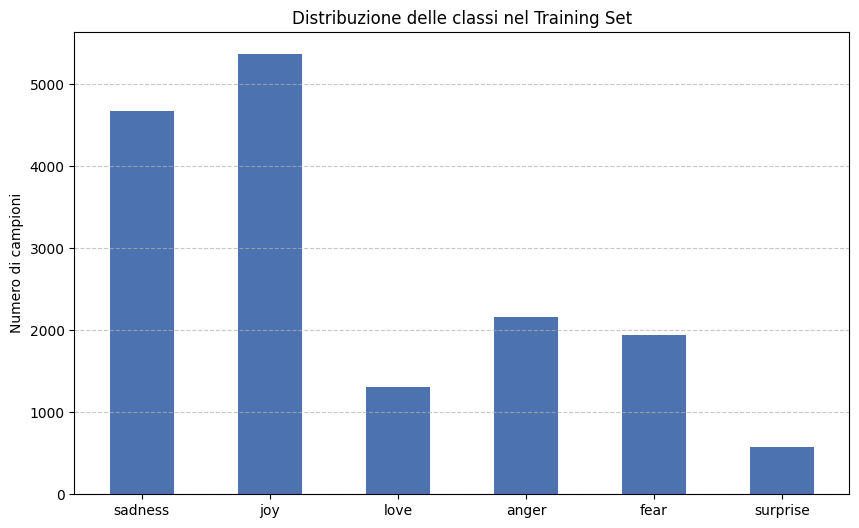

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset = load_dataset("dair-ai/emotion")

# Visualizzare la struttura
print(dataset)

# 2. Convertire in Pandas per una rapida analisi (utile per il Report)
# Vediamo un esempio e le etichette
train_df = pd.DataFrame(dataset['train'])
print(train_df.head())

# Mappatura delle etichette (Label Mapping)
# Nel dataset emotion: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise
labels = dataset['train'].features['label'].names
print(f"Classi disponibili: {labels}")

# Conteggio classi
class_counts = train_df['label'].value_counts().sort_index()
print(class_counts)

# --- GRAFICO SBILANCIAMENTO ---
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, class_counts.values, width=0.5, color='#4c72b0')

ax.set_ylabel('Numero di campioni')
ax.set_title('Distribuzione delle classi nel Training Set')
ax.set_xticks(x)
ax.set_xticklabels([labels[i] for i in class_counts.index])
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Prepare the dataset

In [2]:
from transformers import AutoTokenizer

# Carichiamo il tokenizer specifico di BERTweet
model_checkpoint = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, normalization=True)

# Funzione di tokenizzazione
def preprocess_function(examples):
    # Truncation=True: taglia i testi troppo lunghi
    # Max_length=128: come riportato nel paper di BERTweet-base
    return tokenizer(examples["text"], truncation=True, max_length=128)

# Applichiamo la tokenizzazione a tutto il dataset (Train, Validation, Test)
encoded_dataset = dataset.map(preprocess_function, batched=True)

# Rimuoviamo la colonna 'text' originale perché al modello servono solo i numeri (input_ids)
# Ma teniamo 'label'
encoded_dataset = encoded_dataset.remove_columns(["text"])

# Rinominiamo 'label' in 'labels' perché HuggingFace Trainer si aspetta questo nome esatto
encoded_dataset = encoded_dataset.rename_column("label", "labels")

# Impostiamo il formato per PyTorch
encoded_dataset.set_format("torch")

print("Dataset pronto per il training:")
print(encoded_dataset['train'][0]) # Vedrete 'input_ids', 'token_type_ids', 'attention_mask', 'labels'

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Dataset pronto per il training:
{'labels': tensor(0), 'input_ids': tensor([    0,    37,  1403,   174, 45115,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1])}


## Loading the model

In [3]:
import numpy as np
import evaluate
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Mappatura delle etichette (Utile per leggere i risultati)
# Dal dataset dair-ai/emotion:
id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {"sadness": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}

# 2. Caricamento del Modello Pre-addestrato
# carichiamo BERTweet e specifichiamo che vogliamo 6 output (num_labels=6)
model_checkpoint = "vinai/bertweet-base"
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

model = model.to("xpu") # Spostiamo il modello sulla GPU XPU

# freeze all base model parameters
for name, param in model.base_model.named_parameters():
    param.requires_grad = False


for name, param in model.base_model.named_parameters():
    if "pooler" in name:
        param.requires_grad = True

# -------------------------------------

# Verifica: Stampiamo quanti parametri verranno effettivamente addestrati
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())

print(f"Parametri totali: {all_params:,}")
print(f"Parametri addestrabili (Testa): {trainable_params:,}")
print(f"Percentuale addestrabile: {100 * trainable_params / all_params:.2f}%")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Parametri totali: 134,904,582
Parametri addestrabili (Testa): 595,206
Percentuale addestrabile: 0.44%


## Define evaluation metrics

In [26]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1_score = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    
    return {"accuracy": acc["accuracy"], "f1": f1_score["f1"]}

## Eval base model

In [5]:
from transformers import DataCollatorWithPadding
import intel_extension_for_pytorch as ipex

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Configuriamo argomenti base solo per la valutazione
training_args = TrainingArguments(
    #output_dir="./bertweet-emotion-checkpoints",
    per_device_eval_batch_size=32, # Batch size per valutazione
    report_to="none", # Disabilita wandb/tensorboard per ora
    bf16=True, # Usa mixed precision se supportato (XPU lo supporta, accelera la valutazione
)

# Inizializziamo il Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("--- AVVIO VALUTAZIONE BASELINE (PRE-TRAINING) ---")
baseline_metrics = trainer.evaluate(encoded_dataset["test"])

print("\nRisultati Baseline (Modello non addestrato):")
print(f"Accuracy: {baseline_metrics['eval_accuracy']:.4f}")
print(baseline_metrics['eval_f1'])
print(f"F1-Score: {baseline_metrics['eval_f1']:.4f}")
print("-------------------------------------------------")

--- AVVIO VALUTAZIONE BASELINE (PRE-TRAINING) ---



Risultati Baseline (Modello non addestrato):
Accuracy: 0.0335
0.011230670017418592
F1-Score: 0.0112
-------------------------------------------------


## Hyperparameter tuning transfer learning (Ablation)

In [6]:
import itertools
from torch.optim import AdamW

learning_rates = [1e-3, 1e-04, 1e-05]
batch_sizes = [8, 16]

best_accuracy = 0
best_f1 = 0
best_params = {}
tl_results = []

print(f"--- INIZIO HYPERPARAMETER TUNING (Grid Search) ---")
print(f"Totale combinazioni da testare: {len(learning_rates) * len(batch_sizes)}")

# Iteriamo su tutte le combinazioni
for lr, bs in itertools.product(learning_rates, batch_sizes):
    
    print(f"\nTesting: LR={lr}, Batch={bs}")
    
    # A. RICARICARE IL MODELLO (Fondamentale: ripartiamo da zero ogni volta)
    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/bertweet-base",
        num_labels=6,
        id2label=id2label,
        label2id=label2id
    )

    model = model.to("xpu") # Spostiamo il modello sulla GPU XPU
    
    # B. APPLICARE IL FREEZING (Transfer Learning puro)
    for param in model.base_model.parameters():
        param.requires_grad = False
    
    training_args = TrainingArguments(
        output_dir=f"./tuning_lr{lr}_bs{bs}",
        eval_strategy="epoch",
        save_strategy="no",        # Non salviamo i checkpoint intermedi per risparmiare spazio
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=4,        # Riduciamo a 4 per il tuning (basta per vedere il trend)
        weight_decay=0.01,
        report_to="none",
        load_best_model_at_end=False, # Non serve qui, valutiamo alla fine
        bf16=True # Uso GPU XPU, rimuovere questo se si vuole usare cuda
    )

    optimizer = AdamW(
        model.parameters(),
        lr=lr,
        eps=1e-6 # fp64 non supportato su xpu
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        optimizers=(optimizer, None)  # (optimizer, scheduler) - None = scheduler di default
    )
    
    # E. TRAINING E VALUTAZIONE
    trainer.train()
    eval_result = trainer.evaluate(encoded_dataset["test"])
    acc_score = eval_result['eval_accuracy']
    f1_score = eval_result['eval_f1']
    
    # Salviamo i risultati
    tl_results.append({'lr': lr, 'batch': bs, 'accuracy': acc_score, 'f1': f1_score})
    print(f"--> Risultato: Accuracy = {acc_score:.4f}, F1 = {f1_score:.4f}")
    
    # Aggiorniamo il best model
    if (acc_score + f1_score) > (best_accuracy + best_f1):
        best_accuracy = acc_score
        best_f1 = f1_score
        best_params = {'lr': lr, 'batch': bs}

print("\n---------------------------------------------")
print(f"MIGLIOR RISULTATO TROVATO: Accuracy {best_accuracy:.4f}")
print(f"MIGLIORI PARAMETRI: {best_params}")
print("---------------------------------------------")

# Stampa tabella riassuntiva per il Report
import pandas as pd
df_results = pd.DataFrame(tl_results)
print(df_results.sort_values(by="accuracy", ascending=False))

--- INIZIO HYPERPARAMETER TUNING (Grid Search) ---
Totale combinazioni da testare: 6

Testing: LR=0.001, Batch=8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.461786,1.352520,0.497000,0.223298
2,1.420183,1.324249,0.514500,0.292011
3,1.386966,1.304733,0.532000,0.334523
4,1.296204,1.251992,0.535000,0.307780


--> Risultato: Accuracy = 0.5360, F1 = 0.2933

Testing: LR=0.001, Batch=16


...

--> Risultato: Accuracy = 0.4455, F1 = 0.1736

Testing: LR=1e-05, Batch=16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.570844,1.567842,0.353000,0.088769
2,1.558735,1.557467,0.380500,0.122944
3,1.551869,1.551834,0.385500,0.127244
4,1.542439,1.549934,0.401000,0.142246


--> Risultato: Accuracy = 0.4110, F1 = 0.1510

---------------------------------------------
MIGLIOR RISULTATO TROVATO: Accuracy 0.5415
MIGLIORI PARAMETRI: {'lr': 0.001, 'batch': 16}
---------------------------------------------
        lr  batch  accuracy        f1
1  0.00100     16    0.5415  0.296155
0  0.00100      8    0.5360  0.293261
2  0.00010      8    0.5070  0.218589
3  0.00010     16    0.5040  0.210676
4  0.00001      8    0.4455  0.173642
5  0.00001     16    0.4110  0.151003


## Fine tuning (Transfer learning)

In [7]:
lr = best_params['lr']
batch_size = best_params['batch']
num_epochs = 10

print(f"Usando iperparametri ottimali: LR={lr}, Batch={batch_size}")

training_args = TrainingArguments(
    #output_dir="./bertweet-emotion-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=lr,
    per_device_train_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="tensorboard",
    bf16=True
)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=lr,
    eps=1e-6
)

# Aggiorniamo il trainer con i nuovi argomenti
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    processing_class=tokenizer,
    optimizers=(optimizer, None)
)

print("\n--- AVVIO FINE-TUNING (TRANSFER LEARNING) ---")
trainer.train()

eval_result = trainer.evaluate(encoded_dataset["test"])
best_tl_acc = eval_result['eval_accuracy']
best_tl_f1 = eval_result['eval_f1']

Usando iperparametri ottimali: LR=0.001, Batch=16

--- AVVIO FINE-TUNING (TRANSFER LEARNING) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.460064,1.388607,0.458500,0.197777
2,1.422813,1.321901,0.533000,0.291870
3,1.397227,1.316980,0.525500,0.320086
4,1.368422,1.280861,0.536500,0.306313
5,1.357592,1.322488,0.501000,0.333863
6,1.354343,1.278337,0.534500,0.290929
7,1.340863,1.255670,0.536000,0.280018
8,1.329288,1.224461,0.552000,0.324695
9,1.324684,1.234175,0.549500,0.341733
10,1.305177,1.222045,0.553500,0.353537


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

## Hyperparameter tuning full fine tuning (Ablation)

In [8]:
import itertools
from torch.optim import AdamW

learning_rates = [2e-5, 3e-05, 5e-05]
batch_sizes = [8, 16]

best_accuracy = 0
best_f1 = 0
best_params = {}
ft_results = []

print(f"--- INIZIO HYPERPARAMETER TUNING (Grid Search) ---")
print(f"Totale combinazioni da testare: {len(learning_rates) * len(batch_sizes)}")

for lr, bs in itertools.product(learning_rates, batch_sizes):
    
    print(f"\nTesting: LR={lr}, Batch={bs}")
    
    # A. RICARICARE IL MODELLO
    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/bertweet-base",
        num_labels=6,
        id2label=id2label,
        label2id=label2id
    )

    model = model.to("xpu")
    
    optimizer = AdamW(
        model.parameters(),
        lr=lr,
        eps=1e-6 # fp64 non supportato su xpu
    )
    
    # D. DEFINIRE GLI ARGOMENTI
    training_args = TrainingArguments(
        output_dir=f"./ft_tuning_lr{lr}_bs{bs}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=4,
        weight_decay=0.01,
        report_to="none",
        load_best_model_at_end=False,
        bf16=True
    )
    
    # E. INIZIALIZZARE IL TRAINER
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        optimizers=(optimizer, None)
    )
    
    # F. TRAINING E VALUTAZIONE
    trainer.train()
    eval_result = trainer.evaluate(encoded_dataset["test"])
    acc_score = eval_result['eval_accuracy']
    f1_score = eval_result['eval_f1']
    
    ft_results.append({'lr': lr, 'batch': bs, 'accuracy': acc_score, 'f1': f1_score})
    print(f"--> Risultato: Accuracy = {acc_score:.4f}, F1 = {f1_score:.4f}")
    
    if (acc_score + f1_score) > (best_accuracy + best_f1):
        best_accuracy = acc_score
        best_f1 = f1_score
        best_params = {'lr': lr, 'batch': bs}

print("\n---------------------------------------------")
print(f"MIGLIOR RISULTATO TROVATO: Accuracy {best_accuracy:.4f}")
print(f"MIGLIORI PARAMETRI: {best_params}")
print("---------------------------------------------")

import pandas as pd
df_results = pd.DataFrame(ft_results)
print(df_results.sort_values(by="accuracy", ascending=False))

--- INIZIO HYPERPARAMETER TUNING (Grid Search) ---
Totale combinazioni da testare: 6

Testing: LR=2e-05, Batch=8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.268566,0.222003,0.927000,0.904789
2,0.178536,0.180671,0.937500,0.912411
3,0.131981,0.190026,0.942000,0.917548
4,0.105727,0.180809,0.943000,0.916522


--> Risultato: Accuracy = 0.9325, F1 = 0.8943

Testing: LR=2e-05, Batch=16


...

--> Risultato: Accuracy = 0.9310, F1 = 0.8905

Testing: LR=5e-05, Batch=16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.587224,1.601801,0.275000,0.071895
2,1.584044,1.581195,0.352000,0.086785
3,1.581805,1.587043,0.352000,0.086785
4,1.574968,1.584141,0.352000,0.086785


--> Risultato: Accuracy = 0.3475, F1 = 0.0860

---------------------------------------------
MIGLIOR RISULTATO TROVATO: Accuracy 0.9355
MIGLIORI PARAMETRI: {'lr': 3e-05, 'batch': 8}
---------------------------------------------
        lr  batch  accuracy        f1
2  0.00003      8    0.9355  0.897609
0  0.00002      8    0.9325  0.894273
3  0.00003     16    0.9315  0.888804
4  0.00005      8    0.9310  0.890477
1  0.00002     16    0.9290  0.891042
5  0.00005     16    0.3475  0.085962


## Full fine tuning

In [9]:

lr = best_params['lr']
batch_size = best_params['batch']
num_epochs = 10

print(f"Usando iperparametri ottimali: LR={lr}, Batch={batch_size}")

# A. RICARICARE IL MODELLO
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)
model = model.to("xpu")

optimizer = AdamW(
    model.parameters(),
    lr=lr,
    eps=1e-6
)

training_args = TrainingArguments(
    output_dir="./bertweet-full-finetuning",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=lr,
    per_device_train_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="tensorboard",
    bf16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    processing_class=tokenizer,
    optimizers=(optimizer, None)
)

print("\n--- AVVIO FINE-TUNING (FULL FINE TUNING) ---")
trainer.train()

eval_result = trainer.evaluate(encoded_dataset["test"])
best_full_acc = eval_result['eval_accuracy']
best_full_f1 = eval_result['eval_f1']

Usando iperparametri ottimali: LR=3e-05, Batch=8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi


--- AVVIO FINE-TUNING (FULL FINE TUNING) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.261983,0.200659,0.935500,0.915157
2,0.192916,0.245207,0.932000,0.902279
3,0.151329,0.171343,0.943000,0.918538
4,0.140817,0.206194,0.940500,0.915182
5,0.136828,0.246600,0.941000,0.914715
6,0.105820,0.255707,0.941500,0.917221
7,0.085674,0.321891,0.939500,0.914664
8,0.038721,0.363111,0.942500,0.918310
9,0.033759,0.364376,0.943500,0.919645
10,0.021404,0.384182,0.946500,0.922405


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

## LoRA config tuning (Ablation)

In [10]:
from peft import get_peft_model, LoraConfig, TaskType
import itertools
from torch.optim import AdamW

rangos = [8, 16]
target_modules = [["query", "value", "key", "dense"], ["query", "value"], ["query", "key", "value"]]
learning_rates = [2e-4, 2e-5]
batch_sizes = [8, 16]

best_accuracy = 0
best_f1 = 0
best_configs = {}
lora_results = []

print(f"--- INIZIO LORA CONFIG TUNING (Grid Search) ---")
print(f"Totale combinazioni da testare: {len(rangos) * len(target_modules) * len(learning_rates) * len(batch_sizes)}")

for r, tm, lr, bs in itertools.product(rangos, target_modules, learning_rates, batch_sizes):
    print(f"\nTesting: Rango={r}, Target Modules={tm}, Learning Rate={lr}, Batch Size={bs}")
    
    # Ricarichiamo il modello base
    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/bertweet-base",
        num_labels=6,
        id2label=id2label,
        label2id=label2id
    )
    
    # Configuriamo LoRA
    peft_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        inference_mode=False, 
        r=r,
        lora_alpha=r*2,
        target_modules=tm,
        lora_dropout=0.1,
        modules_to_save=["classifier"]
    )
    
    # Applichiamo LoRA al modello
    model = get_peft_model(model, peft_config)
    model = model.to("xpu")  # dopo get_peft_model, non prima
    
    # Optimizer con eps in fp32
    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        eps=1e-6
    )
    
    # Configuriamo il Trainer con i parametri migliori trovati prima
    training_args = TrainingArguments(
        output_dir=f"./lora_r{r}_tm{'_'.join(tm)}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=4,
        weight_decay=0.01,
        report_to="none",
        load_best_model_at_end=False,
        bf16=True
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=encoded_dataset["train"],
        eval_dataset=encoded_dataset["validation"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        optimizers=(optimizer, None)
    )
    
    trainer.train()
    eval_result = trainer.evaluate(encoded_dataset["test"])
    acc_score = eval_result['eval_accuracy']
    f1_score = eval_result['eval_f1']
    
    lora_results.append({'r': r, 'target_modules': tm, 'learning_rate': lr, 'batch_size': bs, 'accuracy': acc_score, 'f1': f1_score})
    print(f"--> Risultato: Accuracy = {acc_score:.4f}, F1 = {f1_score:.4f}")
    
    if (acc_score + f1_score) > (best_accuracy + best_f1):
        best_accuracy = acc_score
        best_f1 = f1_score
        best_configs = {'r': r, 'target_modules': tm, 'learning_rate': lr, 'batch_size': bs}

print(pd.DataFrame(lora_results))

--- INIZIO LORA CONFIG TUNING (Grid Search) ---
Totale combinazioni da testare: 24

Testing: Rango=8, Target Modules=['query', 'value', 'key', 'dense'], Learning Rate=0.0002, Batch Size=8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.286875,0.311452,0.917000,0.889204
2,0.200124,0.198326,0.933000,0.907044
3,0.151382,0.170590,0.943000,0.920586
4,0.117203,0.171309,0.936500,0.911451


--> Risultato: Accuracy = 0.9315, F1 = 0.8872

Testing: Rango=8, Target Modules=['query', 'value', 'key', 'dense'], Learning Rate=0.0002, Batch Size=16


...

--> Risultato: Accuracy = 0.8400, F1 = 0.7624

Testing: Rango=16, Target Modules=['query', 'key', 'value'], Learning Rate=2e-05, Batch Size=16


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.228682,0.956408,0.654000,0.388018
2,0.770985,0.696373,0.747000,0.549511
3,0.670752,0.609761,0.785000,0.675224
4,0.615387,0.582151,0.795500,0.706818


--> Risultato: Accuracy = 0.7965, F1 = 0.6765
     r              target_modules  learning_rate  batch_size  accuracy  \
0    8  [query, value, key, dense]        0.00020           8    0.9315   
1    8  [query, value, key, dense]        0.00020          16    0.9290   
2    8  [query, value, key, dense]        0.00002           8    0.8925   
3    8  [query, value, key, dense]        0.00002          16    0.8455   
4    8              [query, value]        0.00020           8    0.9190   
5    8              [query, value]        0.00020          16    0.9165   
6    8              [query, value]        0.00002           8    0.7925   
7    8              [query, value]        0.00002          16    0.7455   
8    8         [query, key, value]        0.00020           8    0.9180   
9    8         [query, key, value]        0.00020          16    0.9155   
10   8         [query, key, value]        0.00002           8    0.8175   
11   8         [query, key, value]        0.00002     

## Fine tuning (LoRA)

In [11]:
from peft import get_peft_model, LoraConfig, TaskType

r = best_configs['r']
tm = best_configs['target_modules']
lr = best_configs['learning_rate']
bs = best_configs['batch_size']

model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, # Task: Sequence Classification
    inference_mode=False, 
    r=r,                       # Rango: dimensione delle matrici LoRA (16 è un ottimo bilanciamento)
    lora_alpha=r*2,              # Scaling factor (solitamente 2x r)
    lora_dropout=0.1,           # Un po' di dropout per evitare overfitting
    target_modules=tm, # Dove applicare LoRA (nei layer di self-attention)
    modules_to_save=["classifier"]
)

model = get_peft_model(model, peft_config)
model = model.to("xpu")  # dopo get_peft_model, non prima
    
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=lr,
    eps=1e-6
)


# Stampiamo i parametri addestrabili per il Report
model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir="./bertweet-emotion-lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=lr,
    per_device_train_batch_size=bs,
    per_device_eval_batch_size=bs,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    bf16=True,

    lr_scheduler_type="cosine",      # Questo fa la differenza nelle ultime epoche
    warmup_ratio=0.1,                # 10% di riscaldamento
)

# 5. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"], 
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    optimizers=(optimizer, None)
)

print("\n--- AVVIO FINE-TUNING CON LoRA (Low-Rank Adaptation) ---")
trainer.train()

eval_result = trainer.evaluate(encoded_dataset["test"])
best_lora_acc = eval_result['eval_accuracy']
best_lora_f1 = eval_result['eval_f1']

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

trainable params: 3,249,414 || all params: 138,153,996 || trainable%: 2.3520

--- AVVIO FINE-TUNING CON LoRA (Low-Rank Adaptation) ---


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.361597,0.330312,0.910500,0.884154
2,0.242754,0.245964,0.928500,0.899557
3,0.173367,0.165937,0.943500,0.919658
4,0.148196,0.151404,0.940500,0.915637
5,0.130196,0.148031,0.937000,0.910794
6,0.109224,0.155551,0.939000,0.912367
7,0.087753,0.206584,0.939000,0.914927
8,0.081147,0.218723,0.938500,0.917211
9,0.066809,0.250182,0.942000,0.922257
10,0.061876,0.252590,0.941500,0.921620


## In-context learning (zero-shot)

In [12]:
import torch
from transformers import AutoModelForMaskedLM

model_checkpoint = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

device = "cuda" if torch.cuda.is_available() else "xpu" if torch.xpu.is_available() else "cpu"
model.to(device)
model.eval()

verbalizers_map = {
    0: ["sadness", "sad", "depressed", "grief", "crying", "miserable"],  # sadness
    1: ["joy", "happy", "glad", "excited", "delighted"],      # joy
    2: ["love", "loved", "loving", "sweet", "caring"],        # love
    3: ["anger", "angry", "mad", "furious", "hate", "annoyed"],        # anger
    4: ["fear", "scared", "afraid", "terrified", "nervous"],  # fear
    5: ["surprise", "shocked", "surprised", "amazed", "stunned", "wow"]   # surprise
}

# Otteniamo gli ID dei token per queste parole
verbalizer_ids = {}
for label, words in verbalizers_map.items():
    ids = []
    for w in words:
        token = tokenizer.encode(" " + w, add_special_tokens=False)[0]
        ids.append(token)
    verbalizer_ids[label] = ids

# Carichiamo il dataset
dataset = load_dataset("dair-ai/emotion")
test_dataset = dataset['test'] # 2000 esempi
train_dataset = dataset['train']

# Selezioniamo 1 esempio breve per ogni classe dal train set da usare come contesto
shot_bank = []
for label_id in range(6):
    # Cerchiamo un esempio corto (< 15 parole) per risparmiare token
    candidates = [ex for ex in train_dataset if ex['label'] == label_id and len(ex['text'].split()) < 15]
    if candidates:
        shot_bank.append(candidates[0]) # Ne prendiamo uno a caso (il primo)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie roberta.embeddings.word_embeddings.weight to lm_head.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie lm_head.bias to lm_head.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
RobertaForMaskedLM LOAD REPORT from: vinai/bertweet-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
def predict_emotion_k_shot(text, k=0):
    prompt = ""

    if k > 0:
        selected_shots = shot_bank[:k]
        for shot in selected_shots:
            label_word = verbalizers_map[shot['label']][0]  # Prendiamo la prima parola del verbalizer
            prompt += f"{shot['text']} It makes me feel {label_word}. "

    prompt += f"{text} It makes me feel <mask>."
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128).to(device)
    
    # Troviamo la posizione del token <mask>
    # In BERTweet/RoBERTa il mask token id è solitamente tokenizer.mask_token_id
    mask_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    
    if len(mask_index) == 0:
        return -1  # <mask> troncato

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        
    # Prendiamo i logit solo alla posizione della maschera
    mask_logits = logits[0, mask_index, :]
    
    # Ora guardiamo SOLO i punteggi delle nostre parole target (sad, happy, ecc.)
    # Non ci interessa se il modello predice "hungry", ci interessa quale delle 6 emozioni vince.
    best_score = -float('inf')
    predicted_label = -1
    
    for label, tokens in verbalizer_ids.items():
        class_logits = mask_logits[0, tokens]

        score = torch.sum(torch.exp(class_logits)).item()
        
        if score > best_score:
            best_score = score
            predicted_label = label
            
    return predicted_label

In [14]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

print("Avvio valutazione k-shot (In-Context Learning)...")
    
predictions = []
true_labels = []
icl_results = []

k_values = [0, 1, 2, 3, 4, 5] # Proviamo da 0 a 5 shot

for k in k_values:
    print(f"\nTesting k={k} shot...")
    preds = []
    trues = []
    truncated_count = 0

    for i in tqdm(range(len(test_dataset))): 
        text = test_dataset[i]['text']
        label = test_dataset[i]['label']
        
        pred = predict_emotion_k_shot(text, k)

        if pred == -1:
            truncated_count += 1
            continue
        
        predictions.append(pred)
        true_labels.append(label)

    # Calcolo metriche
    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')

    icl_results.append({'k': k, 'truncated': truncated_count, 'acc': acc, 'f1': f1})
    print(f"--> k={k}: Accuracy={acc:.4f}, F1={f1:.4f} (Troncati: {truncated_count})")

best_icl = max(icl_results, key=lambda x: x['acc'])

print(pd.DataFrame(icl_results))

Avvio valutazione k-shot (In-Context Learning)...

Testing k=0 shot...


100%|██████████| 2000/2000 [00:48<00:00, 41.10it/s]


--> k=0: Accuracy=0.4930, F1=0.2463 (Troncati: 0)

Testing k=1 shot...


100%|██████████| 2000/2000 [00:47<00:00, 41.96it/s]


--> k=1: Accuracy=0.4688, F1=0.2228 (Troncati: 0)

Testing k=2 shot...


...

--> k=3: Accuracy=0.4840, F1=0.2459 (Troncati: 0)

Testing k=4 shot...


100%|██████████| 2000/2000 [00:49<00:00, 40.28it/s]


--> k=4: Accuracy=0.4860, F1=0.2519 (Troncati: 0)

Testing k=5 shot...


100%|██████████| 2000/2000 [00:48<00:00, 40.87it/s]

--> k=5: Accuracy=0.4889, F1=0.2577 (Troncati: 25)
   k  truncated       acc        f1
0  0          0  0.493000  0.246325
1  1          0  0.468750  0.222799
2  2          0  0.475000  0.235495
3  3          0  0.484000  0.245921
4  4          0  0.486000  0.251874
5  5         25  0.488852  0.257740


## Final results

In [15]:
# Uniamo tutti i risultati in un unico DataFrame
all_results = tl_results + lora_results + icl_results
df_final = pd.DataFrame(all_results)

# Formattazione per il report
print("\n=== RISULTATI FINALI STUDIO ABLATION ===")
print(df_final.sort_values(by="accuracy", ascending=True))

# Codice opzionale per salvare in CSV
# df_final.to_csv("ablation_study_results.csv", index=False)


=== RISULTATI FINALI STUDIO ABLATION ===
         lr  batch  accuracy        f1     r              target_modules  \
5   0.00001   16.0    0.4110  0.151003   NaN                         NaN   
4   0.00001    8.0    0.4455  0.173642   NaN                         NaN   
3   0.00010   16.0    0.5040  0.210676   NaN                         NaN   
2   0.00010    8.0    0.5070  0.218589   NaN                         NaN   
0   0.00100    8.0    0.5360  0.293261   NaN                         NaN   
1   0.00100   16.0    0.5415  0.296155   NaN                         NaN   
13      NaN    NaN    0.7455  0.529536   8.0              [query, value]   
17      NaN    NaN    0.7715  0.589144   8.0         [query, key, value]   
25      NaN    NaN    0.7740  0.583561  16.0              [query, value]   
12      NaN    NaN    0.7925  0.667143   8.0              [query, value]   
29      NaN    NaN    0.7965  0.676514  16.0         [query, key, value]   
16      NaN    NaN    0.8175  0.729755   8.0  

## Grafico di confronto

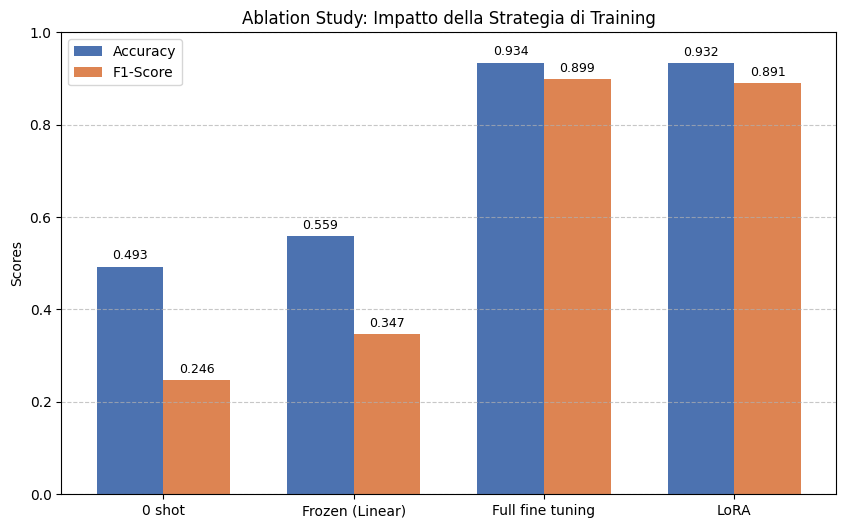

In [18]:
import matplotlib.pyplot as plt
import numpy as np

strategies = [f"{best_icl['k']} shot", 'Frozen (Linear)', 'Full fine tuning', 'LoRA']
accuracies = [best_icl['acc'], best_tl_acc, best_full_acc, best_lora_acc] 
f1_scores =  [best_icl['f1'], best_tl_f1, best_full_f1, best_lora_f1]

x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#4c72b0')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#dd8452')

ax.bar_label(rects1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(rects2, fmt='%.3f', padding=3, fontsize=9)

ax.set_ylabel('Scores')
ax.set_title('Ablation Study: Impatto della Strategia di Training')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Analisi degli errori (Confusion Matrix)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Generazione previsioni sul Validation Set...


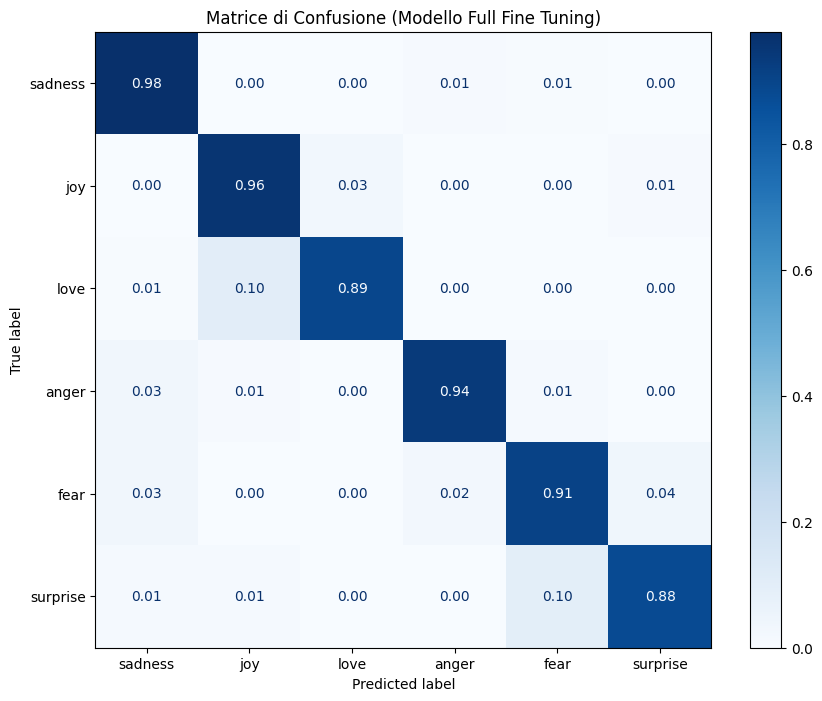

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Carica il tuo modello MIGLIORE
# (Assumiamo che 'trainer' contenga ancora l'ultimo modello addestrato)
# Se hai chiuso la sessione, ricaricalo con:
model = AutoModelForSequenceClassification.from_pretrained("./bertweet-full-finetuning/checkpoint-20000/")
inference_args = TrainingArguments(
    output_dir="./tmp",
    report_to="none"
)
trainer = Trainer(model=model, args=inference_args, compute_metrics=compute_metrics, data_collator=data_collator)

print("Generazione previsioni sul Validation Set...")
predictions = trainer.predict(encoded_dataset["validation"])
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

# 2. Calcola la matrice
cm = confusion_matrix(labels, preds, normalize='true') # Normalize='true' mostra le percentuali

# 3. Disegna
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label2id.keys()))
disp.plot(cmap='Blues', ax=ax, values_format='.2f')
plt.title("Matrice di Confusione (Modello Full Fine Tuning)")
plt.show()